# Student Result Analysis

# 1. Introduction

Student Result Analysis is a data analysis project that explores student academic performance using Python. The dataset contains information about students' demographic and educational backgrounds along with their Math, Reading, and Writing scores.

In this project, I cleaned and analyzed the dataset using Pandas and used Matplotlib and Seaborn to create visualizations. The analysis focuses on understanding student performance and identifying patterns between academic scores and factors such as gender, parental education, parental marital status, ethnic group, weekly study hours, and test preparation.

## 2. Project Objective

The main objectives of this project are:

- To understand and clean the student dataset.
- To analyze the distribution of students based on different categories.
- To calculate and compare average Math, Reading, and Writing scores.
- To study how parental education may be related to student performance.
- To analyze the relationship between weekly study hours and academic scores.
- To examine the effect of test preparation on student performance.
- To identify useful patterns and insights from the dataset using data visualization.

# 3. Importing Libraries

In [ ]:
# pip install pandas
# pip install numpy
# pip install matplotlib
# pip install seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Loading Dataset

In [2]:
df = pd.read_csv("Student_data.csv")
print(df.head())

   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

## 5. Understanding the Dataset

In [62]:
df.shape

(30641, 14)

In [3]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [5]:
df.isnull().sum()


Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

## 6. Data Cleaning

#Drop unnamed column

In [7]:
df = df.drop("Unnamed: 0", axis = 1)
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


#Change weekly study hours column

In [90]:
df["WklyStudyHours"] = df["WklyStudyHours"].str.strip()
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore,TotalScore,AverageScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74,216,72.000000
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91,271,90.333333
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42,143,47.666667
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75,229,76.333333


# 7. Exploratory Data Analysis

# (a). Gender Distribution

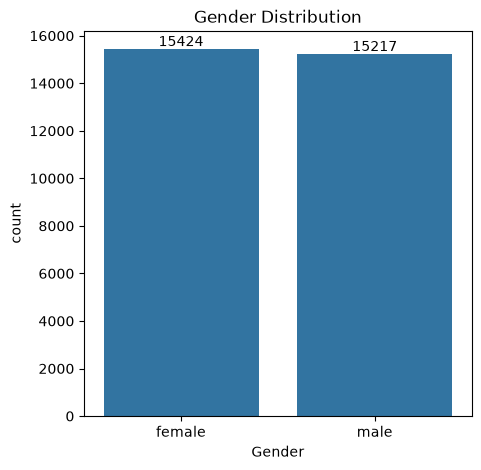

In [23]:
plt.figure(figsize= (5,5))
ax = sns.countplot(data = df, x = "Gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

#From the above chart we have analysed that: the number of females in the data is more than the number of males

# (b). Parent Education

In [14]:
gb = df.groupby("ParentEduc").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


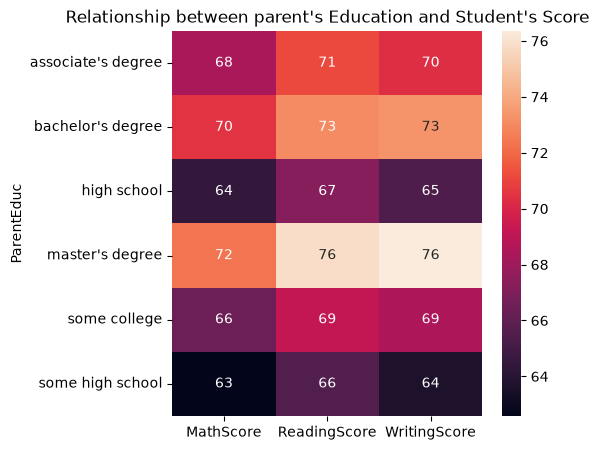

In [24]:
plt.figure(figsize= (5,5))
sns.heatmap(gb, annot = True)
plt.title("Relationship between parent's Education and Student's Score")
plt.show()

#from the above chart we have concluded that the education of the parents havea good impact on their scors

# (c). Parent Marital Status

In [19]:
gb1 = df.groupby("ParentMaritalStatus").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


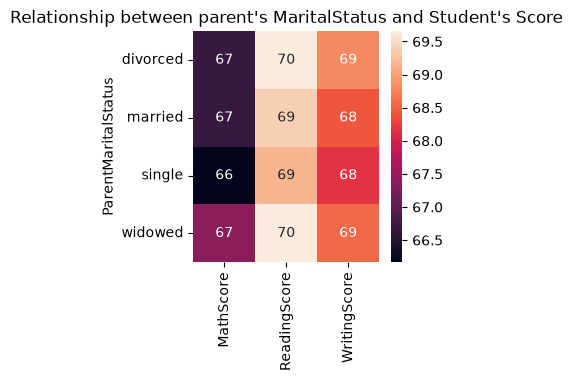

In [96]:
plt.figure(figsize= (3,3))
sns.heatmap(gb1, annot = True)
plt.title("Relationship between parent's MaritalStatus and Student's Score")
plt.show()

#from the above chart we have conclude that there is no/negligible 
impact on the student's score due to the MaritalStatus 

# (d). First Child

In [80]:
gb2 = df.groupby("IsFirstChild").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb2)

              MathScore  ReadingScore  WritingScore
IsFirstChild                                       
no            66.246832     69.132614     68.210887
yes           66.740646     69.542553     68.558484


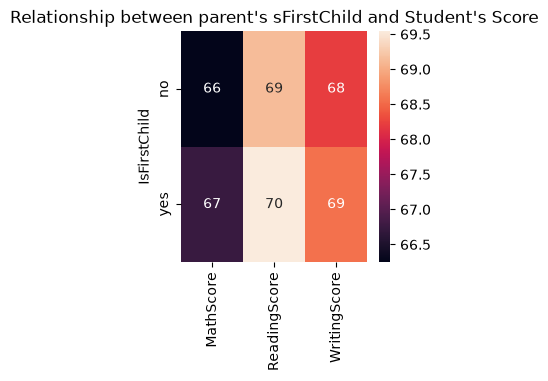

In [34]:
plt.figure(figsize= (3,3))
sns.heatmap(gb2, annot = True)
plt.title("Relationship between parent's sFirstChild and Student's Score")
plt.show()

#from the above chart we have conclude that there is no/negligible impact on the student's score due to the isFirstchild or not

# (e). Analysis for WklyStudyHours

In [82]:
study_hours = df.groupby("WklyStudyHours").agg({
    "MathScore": "mean",
    "ReadingScore": "mean",
    "WritingScore": "mean"
})

print(study_hours)

                MathScore  ReadingScore  WritingScore
WklyStudyHours                                       
5 - 10          66.870491     69.660532     68.636280
< 5             64.580359     68.176135     67.090192
> 10            68.696655     70.365436     69.777778


#Relationship Between Weekly Study Hours and Student Scores

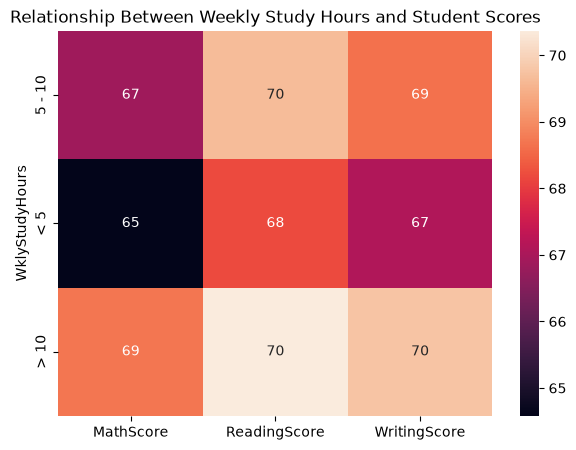

In [92]:
plt.figure(figsize=(7,5))
sns.heatmap(study_hours, annot=True)
plt.title("Relationship Between Weekly Study Hours and Student Scores")
plt.show()

# (f). Distrubution Of Ethnic Group

In [103]:
print(df["EthnicGroup"].unique())

<ArrowStringArray>
[nan, 'group C', 'group B', 'group A', 'group D', 'group E']
Length: 6, dtype: str


[np.int64(2219), np.int64(5826), np.int64(9212), np.int64(7503), np.int64(4041)]


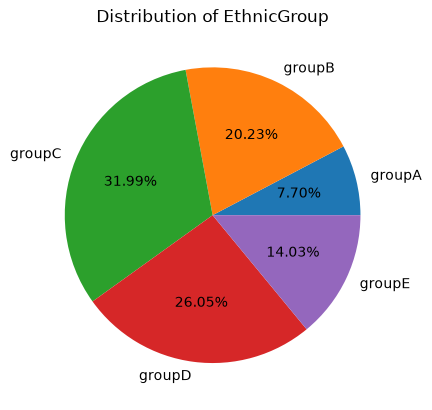

In [104]:
groupA = df.loc[(df['EthnicGroup'] == "group A")].count()
groupB = df.loc[(df['EthnicGroup'] == "group B")].count()
groupC = df.loc[(df['EthnicGroup'] == "group C")].count()
groupD = df.loc[(df['EthnicGroup'] == "group D")].count()
groupE = df.loc[(df['EthnicGroup'] == "group E")].count()
l =["groupA","groupB","groupC","groupD","groupE"]
mlist = [groupA["EthnicGroup"],groupB["EthnicGroup"],groupC["EthnicGroup"],groupD["EthnicGroup"],groupE["EthnicGroup"]]
print(mlist)
plt.pie(mlist, labels = l, autopct = "%1.2f%%")

plt.title("Distribution of EthnicGroup")
plt.show()

[Text(0, 0, '9212'),
 Text(0, 0, '5826'),
 Text(0, 0, '2219'),
 Text(0, 0, '7503'),
 Text(0, 0, '4041')]

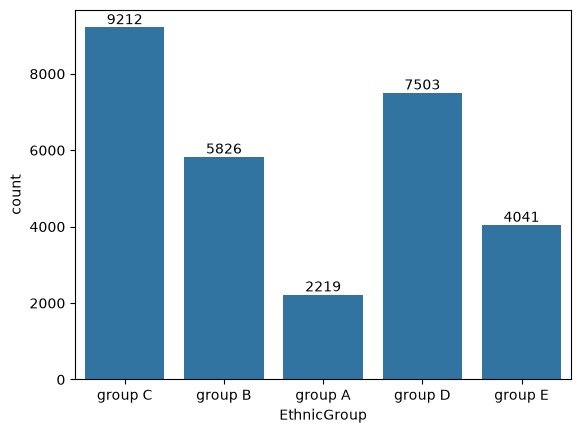

In [105]:
ax = sns.countplot(data = df, x = 'EthnicGroup')
ax.bar_label(ax.containers[0])

# (g). Score Analysis

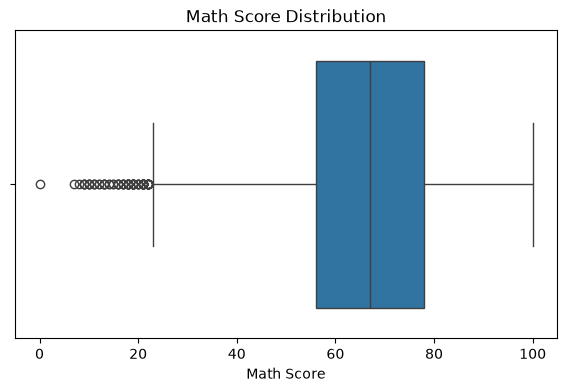

In [93]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="MathScore")

plt.title("Math Score Distribution")
plt.xlabel("Math Score")

plt.show()

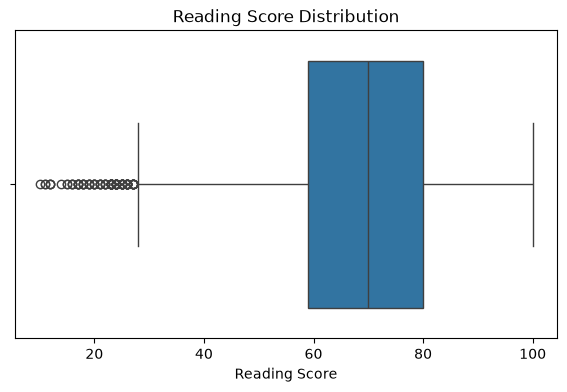

In [94]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="ReadingScore")

plt.title("Reading Score Distribution")
plt.xlabel("Reading Score")

plt.show()

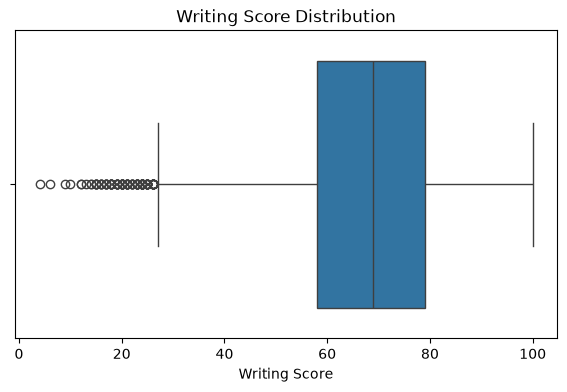

In [95]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="WritingScore")

plt.title("Writing Score Distribution")
plt.xlabel("Writing Score")

plt.show()

In [97]:
df["TotalScore"] = (
    df["MathScore"] +
    df["ReadingScore"] +
    df["WritingScore"]
)

In [98]:
df["AverageScore"] = df[
    ["MathScore", "ReadingScore", "WritingScore"]
].mean(axis=1)

In [99]:
df[["MathScore", "ReadingScore", "WritingScore",
    "TotalScore", "AverageScore"]].head()

,MathScore,ReadingScore,WritingScore,TotalScore,AverageScore
0,71,71,74,216,72.000000
1,69,90,88,247,82.333333
2,87,93,91,271,90.333333
3,45,56,42,143,47.666667
4,76,78,75,229,76.333333


In [100]:
df.sort_values("TotalScore", ascending=False).head(10)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore,TotalScore,AverageScore
30605,female,group E,master's degree,standard,NaN,married,sometimes,no,2.0,school_bus,5 - 10,100,100,100,300,100.0
30060,female,group D,bachelor's degree,standard,completed,married,regularly,no,1.0,school_bus,5 - 10,100,100,100,300,100.0
3460,male,group E,bachelor's degree,free/reduced,completed,divorced,sometimes,yes,0.0,school_bus,> 10,100,100,100,300,100.0
2683,male,group D,associate's degree,standard,completed,married,regularly,no,1.0,NaN,> 10,100,100,100,300,100.0
23353,male,group E,associate's degree,standard,completed,married,sometimes,no,3.0,private,> 10,100,100,100,300,100.0
432,female,group E,bachelor's degree,standard,none,married,regularly,NaN,2.0,school_bus,NaN,100,100,100,300,100.0
26527,male,group E,bachelor's degree,standard,completed,married,regularly,yes,1.0,school_bus,> 10,100,100,100,300,100.0
4935,female,group E,master's degree,standard,completed,divorced,regularly,yes,2.0,private,> 10,100,100,100,300,100.0
2983,male,group D,master's degree,standard,completed,married,sometimes,no,2.0,school_bus,5 - 10,100,100,100,300,100.0
981,female,group E,high school,standard,completed,divorced,regularly,yes,1.0,private,5 - 10,100,100,100,300,100.0


# (h). Add Test Preparation analysis

In [84]:
test_prep = df.groupby("TestPrep").agg({
    "MathScore": "mean",
    "ReadingScore": "mean",
    "WritingScore": "mean"
})

print(test_prep)

           MathScore  ReadingScore  WritingScore
TestPrep                                        
completed   69.54666     73.732998     74.703265
none        64.94877     67.051071     65.092756


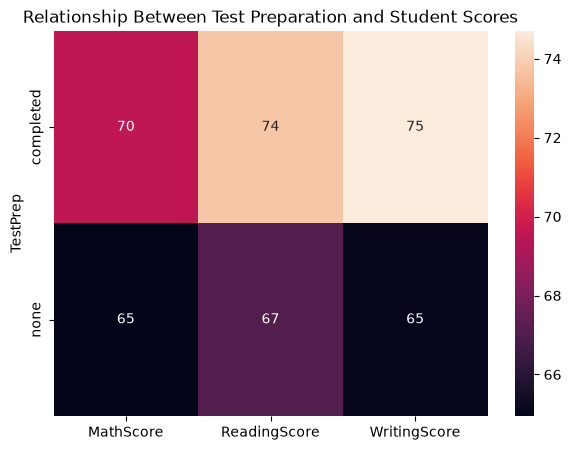

In [85]:
plt.figure(figsize=(7,5))
sns.heatmap(test_prep, annot=True)
plt.title("Relationship Between Test Preparation and Student Scores")
plt.show()

## Key Insights

- The dataset contains students from different gender and ethnic groups, providing a diverse basis for analyzing academic performance.

- Students' Math, Reading, and Writing scores vary across different parental education levels.

- The analysis of parental marital status shows differences in the average academic scores among the categories.

- Weekly study hours can be compared with students' average scores to understand whether study time is associated with academic performance.

- Test preparation is an important factor to analyze because students who completed test preparation may show different average scores compared with students who did not.

- Math, Reading, and Writing scores have different distributions, which can be observed through boxplots.

- The analysis shows that student performance can be studied from multiple factors rather than looking at only one subject or one demographic category.

## Conclusion

This project provided an overview of student academic performance using Python-based data analysis. The dataset was cleaned and explored using Pandas, while Matplotlib and Seaborn were used to visualize different patterns in the data.

The analysis examined factors such as gender, ethnic group, parental education, parental marital status, weekly study hours, and test preparation in relation to students' Math, Reading, and Writing scores.

Overall, the project demonstrates how data analysis and visualization can be used to understand student performance and identify patterns in educational data. This project also helped me strengthen my skills in Python, Pandas, Matplotlib, Seaborn, data cleaning, exploratory data analysis, and data visualization.